In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,BatchNormalization,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import image_dataset_from_directory

In [93]:
# generators 
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/competitions/paddy-disease-classification/train_images',
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
    validation_split = 0.2,
    subset = 'training',
    seed = 42,
    verbose=True,
)

val_ds =  keras.utils.image_dataset_from_directory(
    directory = '/kaggle/input/competitions/paddy-disease-classification/train_images',
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
    validation_split = 0.2,
    subset = 'validation',
    seed = 42,
    verbose=True,
)

Found 10407 files belonging to 10 classes.
Using 8326 files for training.
Found 10407 files belonging to 10 classes.
Using 2081 files for validation.


In [94]:
df = pd.read_csv('/kaggle/input/competitions/paddy-disease-classification/train.csv')

In [95]:
df.head()

,image_id,label,variety,age
0,100330.jpg,bacterial_leaf_blight,ADT45,45
1,100365.jpg,bacterial_leaf_blight,ADT45,45
2,100382.jpg,bacterial_leaf_blight,ADT45,45
3,100632.jpg,bacterial_leaf_blight,ADT45,45
4,101918.jpg,bacterial_leaf_blight,ADT45,45


In [96]:
df.shape

(10407, 4)

In [97]:
print(df['label'].value_counts())
print(df['age'].unique())

label
normal                      1764
blast                       1738
hispa                       1594
dead_heart                  1442
tungro                      1088
brown_spot                   965
downy_mildew                 620
bacterial_leaf_blight        479
bacterial_leaf_streak        380
bacterial_panicle_blight     337
Name: count, dtype: int64
[45 50 55 60 65 68 70 72 47 77 67 73 75 80 62 66 57 82]


In [98]:
df.isnull().sum()

image_id    0
label       0
variety     0
age         0
dtype: int64

In [99]:
# Normalization
def process(image,lable):
    image = tf.cast(image/255.,tf.float32)
    return image,lable

train_ds = train_ds.map(process)
val_ds = val_ds.map(process)


In [100]:
model = Sequential([
    Conv2D(filters = 32,kernel_size = (3,3),activation = 'relu',input_shape = (256,256,3)),
    BatchNormalization(),
    MaxPooling2D(),
    
    Conv2D(filters = 64,kernel_size = (3,3),activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(),
    
    Conv2D(filters = 128,kernel_size = (3,3),activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(),
    
    Conv2D(filters = 128,kernel_size = (3,3),activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(128, activation = 'relu'),
    Dropout(0.1),
    Dense(64,activation = 'relu'),
    Dropout(0.1),
    Dense(10,activation= 'softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [101]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [102]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

In [ ]:
history = model.fit(train_ds,epochs = 20,validation_data = val_ds,callbacks = [early_stop])

Epoch 1/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 26s 74ms/step - accuracy: 0.3155 - loss: 2.2964 - val_accuracy: 0.1735 - val_loss: 3.7195
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.4661 - loss: 1.6066 - val_accuracy: 0.4118 - val_loss: 1.8755
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.5533 - loss: 1.3480 - val_accuracy: 0.5988 - val_loss: 1.3249
Epoch 4/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.6361 - loss: 1.1053 - val_accuracy: 0.6780 - val_loss: 1.0283
Epoch 5/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7042 - loss: 0.9094 - val_accuracy: 0.5387 - val_loss: 1.8524
Epoch 6/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7580 - loss: 0.7443 - val_accuracy: 0.7588 - val_loss: 0.7954
Epoch 7/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.8001 - loss: 0.6077 - val_accuracy: 0.8039 - val_loss: 0.6635
Epoch 8/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.8347 - loss: 0.5217 - 

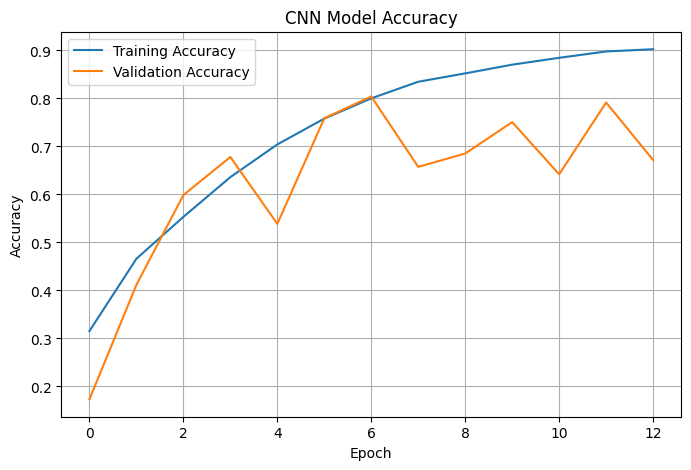

In [108]:

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

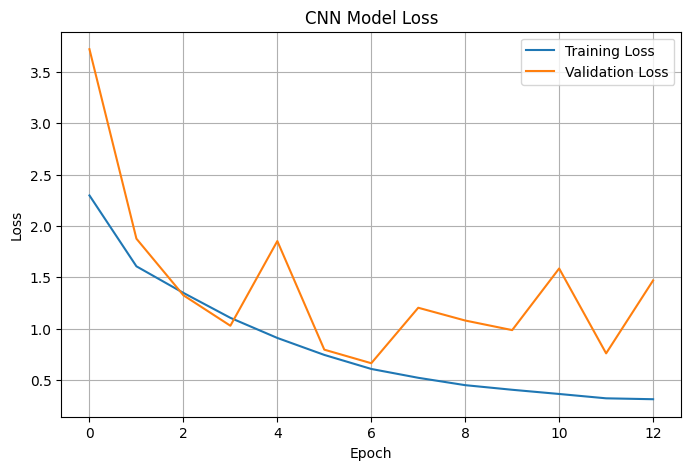

In [109]:

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [110]:
import os
test_dir = '/kaggle/input/competitions/paddy-disease-classification/test_images'

filenames = sorted(os.listdir(test_dir))
filepaths = [os.path.join(test_dir, f) for f in filenames]

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (256, 256))
    img = img / 255.
    return img

test_ds_kaggle = tf.data.Dataset.from_tensor_slices(filepaths).map(load_and_preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

In [111]:
class_names = sorted(os.listdir('/kaggle/input/competitions/paddy-disease-classification/train_images'))
print(class_names)

preds = model.predict(test_ds_kaggle, verbose=1)
pred_indices = np.argmax(preds, axis=1)
pred_labels = [class_names[i] for i in pred_indices]

submission = pd.DataFrame({
    'image_id': filenames,
    'label': pred_labels
})
submission.to_csv('/kaggle/working/submission.csv', index=False)
submission.head()

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step


,image_id,label
0,200001.jpg,hispa
1,200002.jpg,normal
2,200003.jpg,downy_mildew
3,200004.jpg,blast
4,200005.jpg,blast
